### Beat Frequency
Script created to calculate the beat frequency based on the chirp parameters of the LFMW signal and the range of the target, in this case simulated as a fiber)

In [7]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [10]:
c = 3e8 # light velocity [m/s]
B = 0.50e9 # bandwidth [Hz], 20
T = 1e-7 # period of the chirp [s],  2e-6
l_fiber = 100 # length of the fiber [m]
vg = 2e8 # group velocity of the fiber [m/s]
time_window = 2e-6 # time window of the simulation 4 
# This simulation is when we have a fiber acting as a target
# tau = l_fiber / vg 

k = B / T # chirp slope [Hz/s]

# In the case we have an electrical delay
r = 6 # range [m]
tau = 2 * B * r / (c * T * k)

f_beat =2 * k *  tau  # de-chirped frequency
f_res = 1 / time_window # frequency resolution of the simulation


f0 = 10000000000.0;
B = 500000000.0;
T = 1e-07;
k = B/T;
t_mod = mod(TIME, T);
OUTPUT = 0.25*sin(2*pi*(f0*t_mod + 0.5*k*t_mod^2));

In [11]:
print(f'Bandwidth: {B/1e6:.2f} MHz')
print(f'Period :{T/1e-6} us')
print(f'Length of the fiber (range - target): {l_fiber:.2f} m')
print(f'Tau (time delay - range): {tau/1e-6} us')
print(f'Chirp period: {k/1e6:.2f} MHz/s')
print(f'Beat frequency: {f_beat/1e6:.2f} MHz')
print(f'Frequency resolution: {f_res/1e3} KHz')

Bandwidth: 500.00 MHz
Period :0.1 us
Length of the fiber (range - target): 100.00 m
Tau (time delay - range): 0.04 us
Chirp period: 5000000000.00 MHz/s
Beat frequency: 400.00 MHz
Frequency resolution: 500.0 KHz


the condition for a valid beat is: tau < T (delay must be much less than the chirp period)

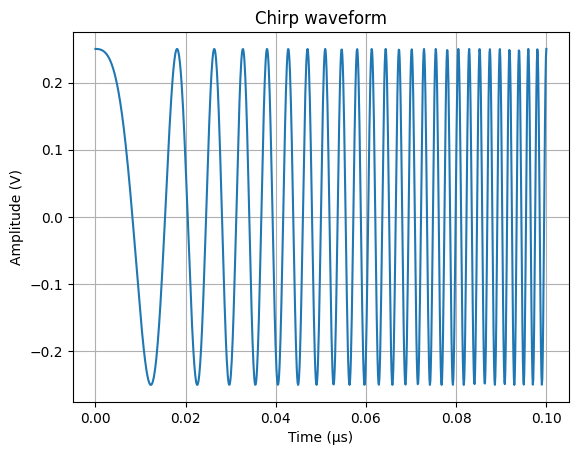

<Figure size 640x480 with 0 Axes>

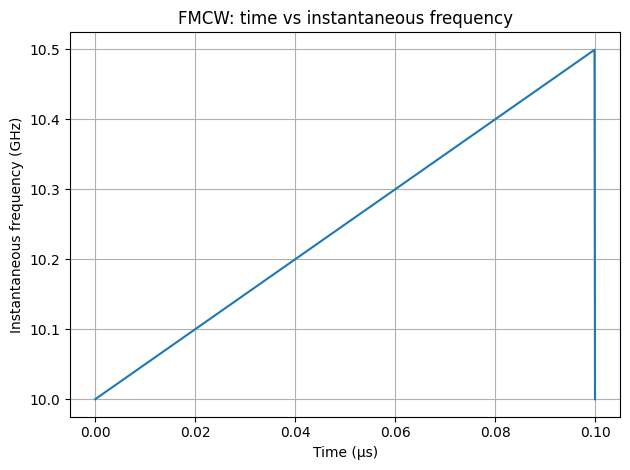

In [12]:
rf_freq1 = 10e9 # Hz
Vp = 0.25  # peak voltage
t = np.linspace(0, T, 1000)  # 0.5 us for example
t_mod = np.mod(t, T)  # modulo operation
signal_out = Vp * np.cos(2 * np.pi * (rf_freq1 * t_mod + 0.5 * k * t_mod ** 2))

f_inst = rf_freq1 + k * t_mod # instantaneous frequency (analytic)  -> f_ins (t) = f0 + k * tm_mod

# plot the waveform (as you had)
plt.figure()
plt.plot(t * 1e6, signal_out)
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude (V)")
plt.title("Chirp waveform")
plt.grid(True)
plt.show()
plt.tight_layout()

# plot instantaneous frequency
plt.figure()
plt.plot(t * 1e6, f_inst * 1e-9)
plt.xlabel("Time (µs)")
plt.ylabel("Instantaneous frequency (GHz)")
plt.title("FMCW: time vs instantaneous frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

### Equation
The signal that modulates the MZM1 at the transmitter, features an instantaneous frequency of $f_{1} + kT$ that linearly changes from $f_1$ to $f_{1} + kT$ with a bandwidth of $B = kT$, where T is the waveform period. 
Biasing at the MZM1 at the null transmission point, leads to a carrier-suppressed double-sideband (CS-DSB) modulation process that projects the input microwave signal into 2 optical sidebands with frequencies of
\begin{equation}
f_{c} + f_{1} + kt
\end{equation}
\begin{equation}
f_{c} - f_{1} - kt
\end{equation}



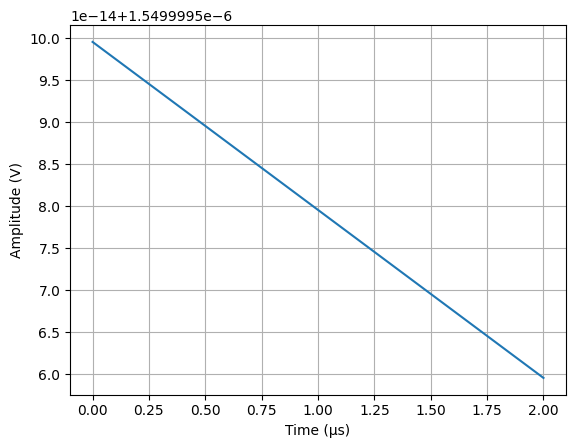

<Figure size 640x480 with 0 Axes>

In [5]:
lambda_c = 1.55e-6 # nm, carrier frequency
c = 3e9 # [m/s]
fc = c / lambda_c # carrier frequency
f1 = rf_freq1

# 1st order optical sidebands
osb1_1 = fc + f1 + k * t
osb1_2 = fc - f1 - k * t

# to nm
osb1_1_w = c / osb1_1
osb1_2_w = c / osb1_2

# print(f"$f_{c} + f_{1} + kt: {osb1_1/1e15} $ Hz, {osb1_1_w/1e6} m")
# print(f"$f_{c} - f_{1} - kt: {osb1_2/1e15}$ Hz, {osb1_2_w/1e6} m")

# plot the waveform (as you had)
plt.figure()
plt.plot(t * 1e6, osb1_1_w)
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude (V)")
# plt.title("Chirp waveform")
plt.grid(True)
plt.show()
plt.tight_layout()


Afterwards the modulated optical signal will be amplified and then split with an MMI (50%/50%). The optical signal in the transmitter goes to a high-speed PD - PD1, to generate a mmWave radar waveform whose initial frequency ($2f_{1}$), and bandwidth ($B_{2}=2kT = 2B$) are both doubled

After the signal is emitted at the free space by an antenna or by a fiber (in my specific case). Then the emitted signal, encounters a target that will be reflected with a time delay of $\tau$. The reflected echo waveform is detected by a receiving antenna, amplified by a LNA, and sent to the receiver, that will perform the de-chirp on the MZM$_{2}$. The MZM$_2$ is connected to the reference chirped signal that was splitted on the transmitter. Now, we have 2 carrier frequencies of:
\begin{equation}
f_{c} + f_{1} + kt
\end{equation}
\begin{equation}
f_{c} - f_{1} - kt
\end{equation}

which are also modulated by the amplified instantaneous frequency of $2f_{1}+2kt - 2k\tau$.
Setting the modulator at quadrature bias, four new optical sidebands are generated, or which 2 sidebands are at the frequencies
\begin{equation}
f_{c} + f_{1} + kt - 2k\tau
\end{equation}
\begin{equation}
f_{c} - f_{1} - kt + 2k\tau
\end{equation}

With this, we can achieve the frequency de-chirp and obtain the low-frequency target information - $2k\tau$, by beating these 2 relevant sidebands at a low -speed PD.

In [6]:
osb2_1 = fc + f1 + k*t - 2*k*tau
osb2_2 = fc - f1 - k*t - 2*k*tau
